<a href="https://colab.research.google.com/github/rathoretina07/Assignments-SIP-/blob/main/Copy_of_Tina_Rathore_Assignment_6_SIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#necessary imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#QUESTION 1

In [ ]:

df = pd.read_csv('/content/data - data (1).csv')
 # change filename as needed
df.columns = df.columns.str.strip().str.lower()

print(df.head())  # displays first 5 row

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

In [ ]:
#USING GITHUB TO GET DATA DIRECTLY FROM WEBSITE
link = "https://raw.githubusercontent.com/plotly/datasets/master/data.csv"
dataaa = pd.read_csv(link)
df1 = dataaa
print(df.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

## b. Visualize and comment on the nature of data.

['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


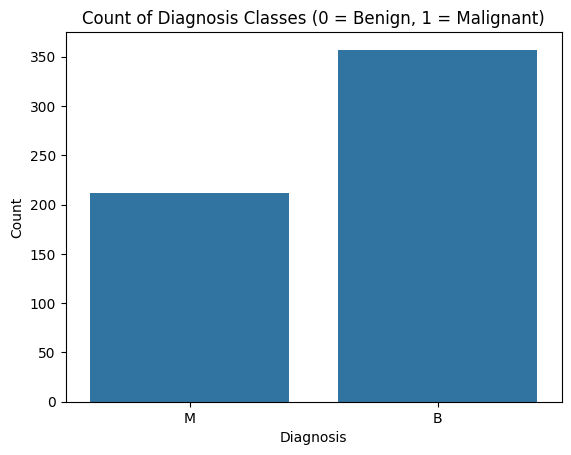

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Strip whitespace from column names if any
df.columns = df.columns.str.strip()
df.head()
# Check columns
print(df.columns.tolist())

# Plot
sns.countplot(x='diagnosis', data=df)
plt.title("Count of Diagnosis Classes (0 = Benign, 1 = Malignant)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()



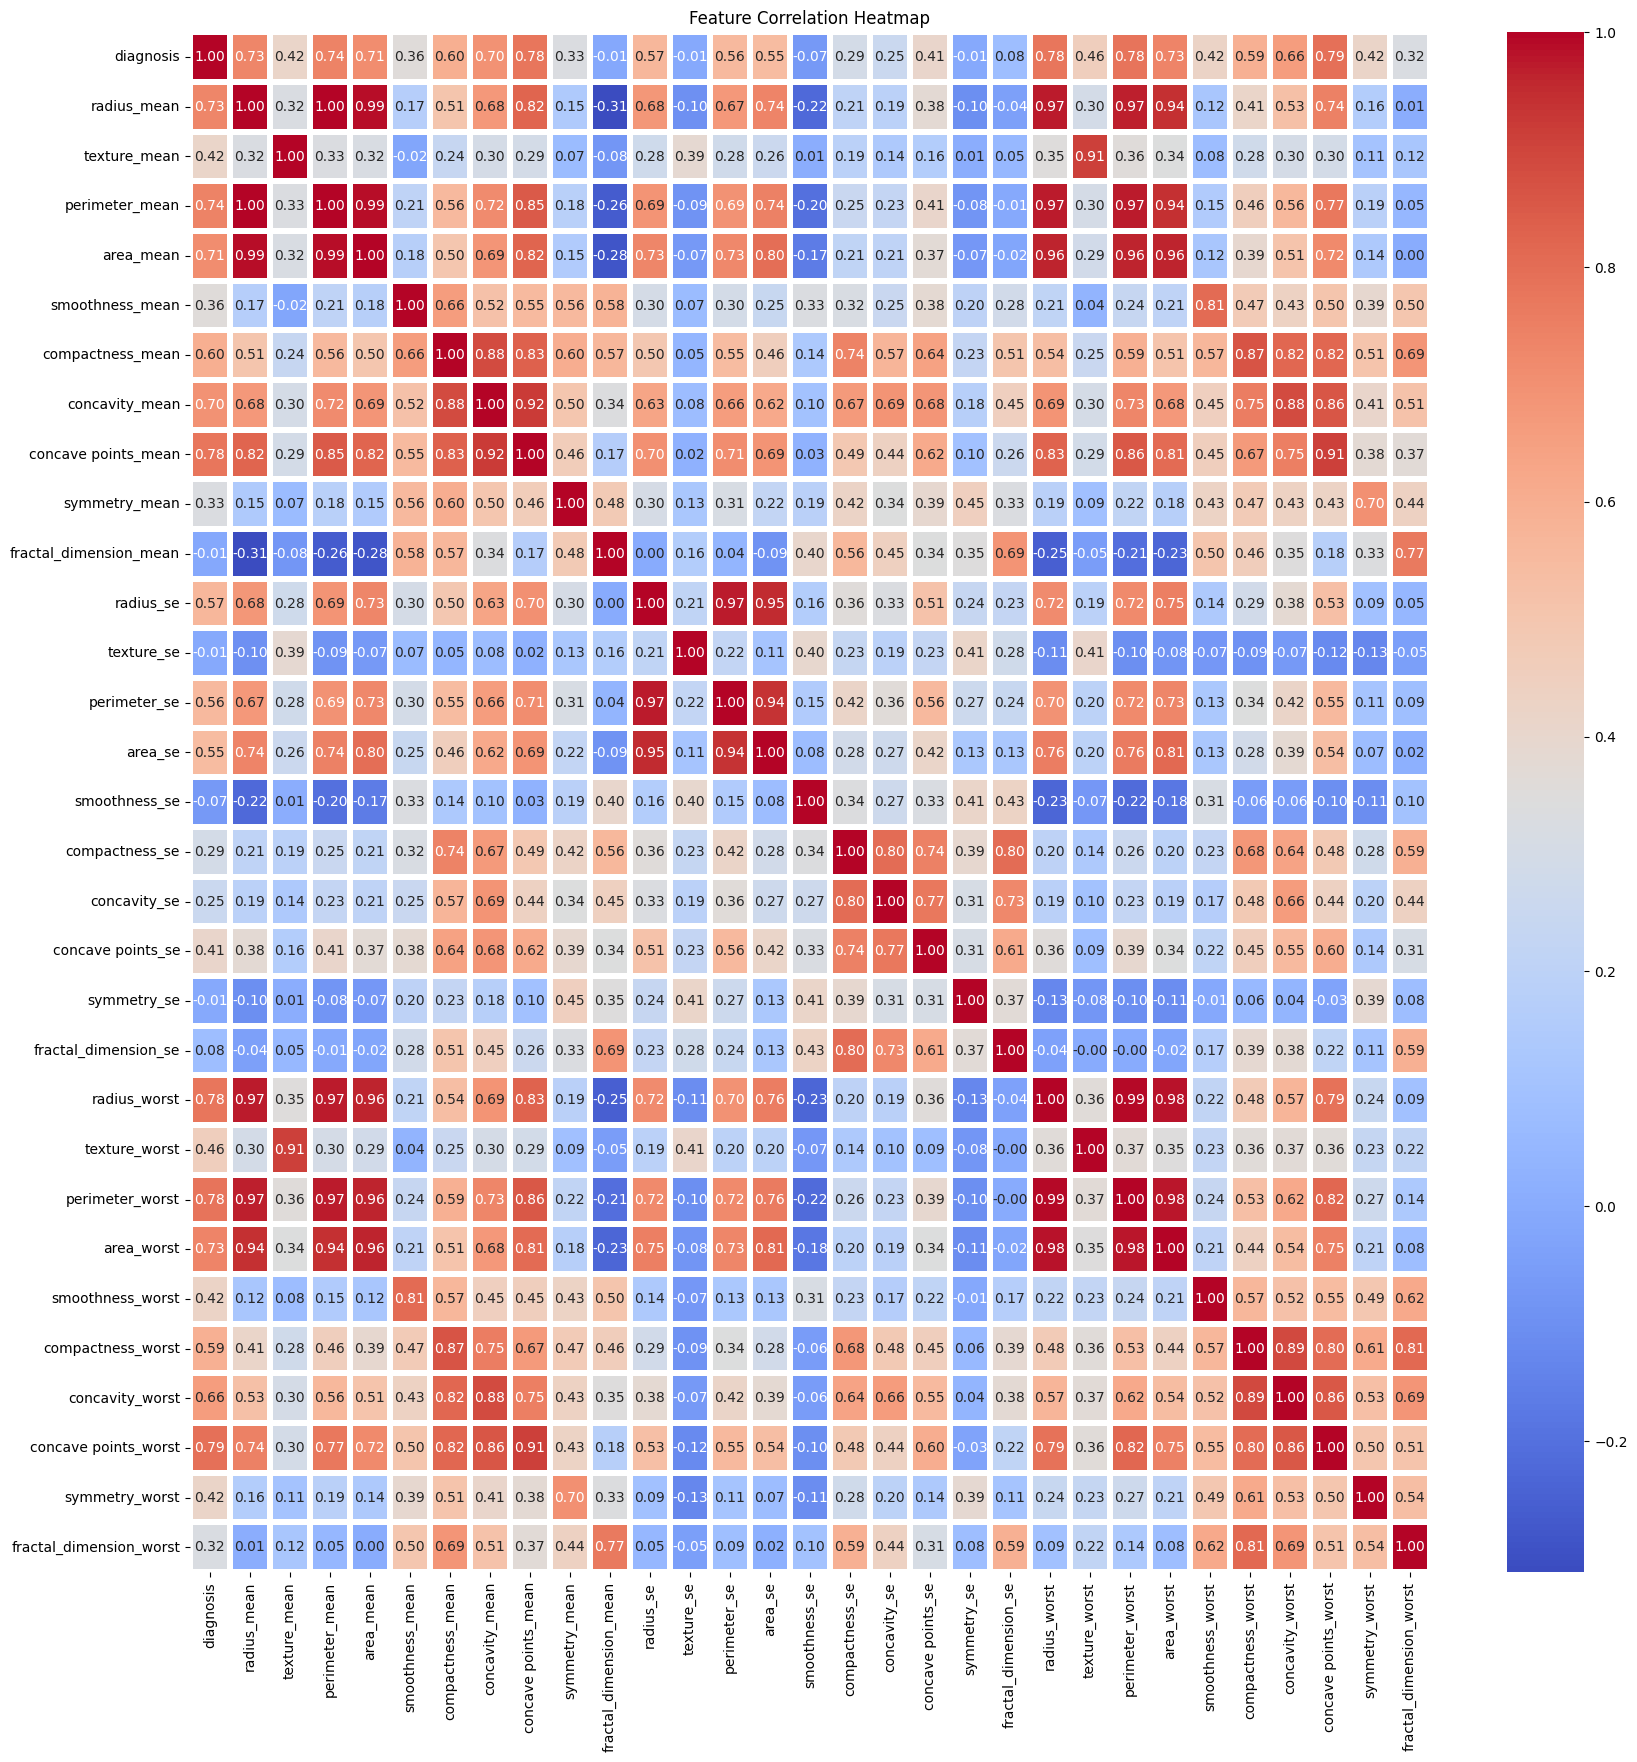

In [ ]:
df['diagnosis']=df['diagnosis'].map({'M':1,'B':0})
corr = df.drop(['id'],axis=1).corr()
plt.figure(figsize=(20,20))
sns.heatmap(corr, cmap='coolwarm',annot=True,fmt=".2f", linewidth='3')
plt.title('Feature Correlation Heatmap')
plt.show()

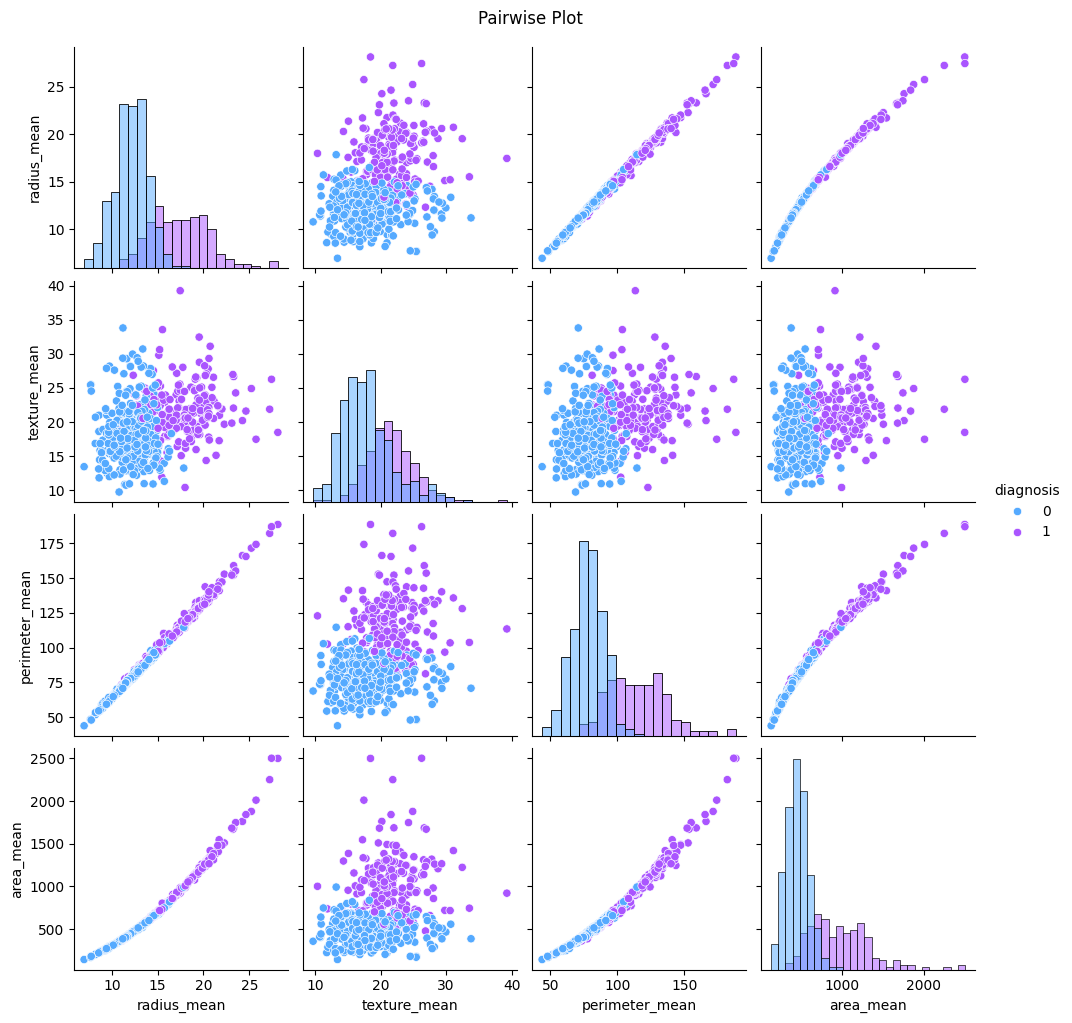

In [ ]:
selected_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'diagnosis']
sns.pairplot(df[selected_features], hue='diagnosis', diag_kind='hist', palette='cool')

plt.suptitle("Pairwise Plot", y=1.02) # Here we add title to show the separately
plt.show()

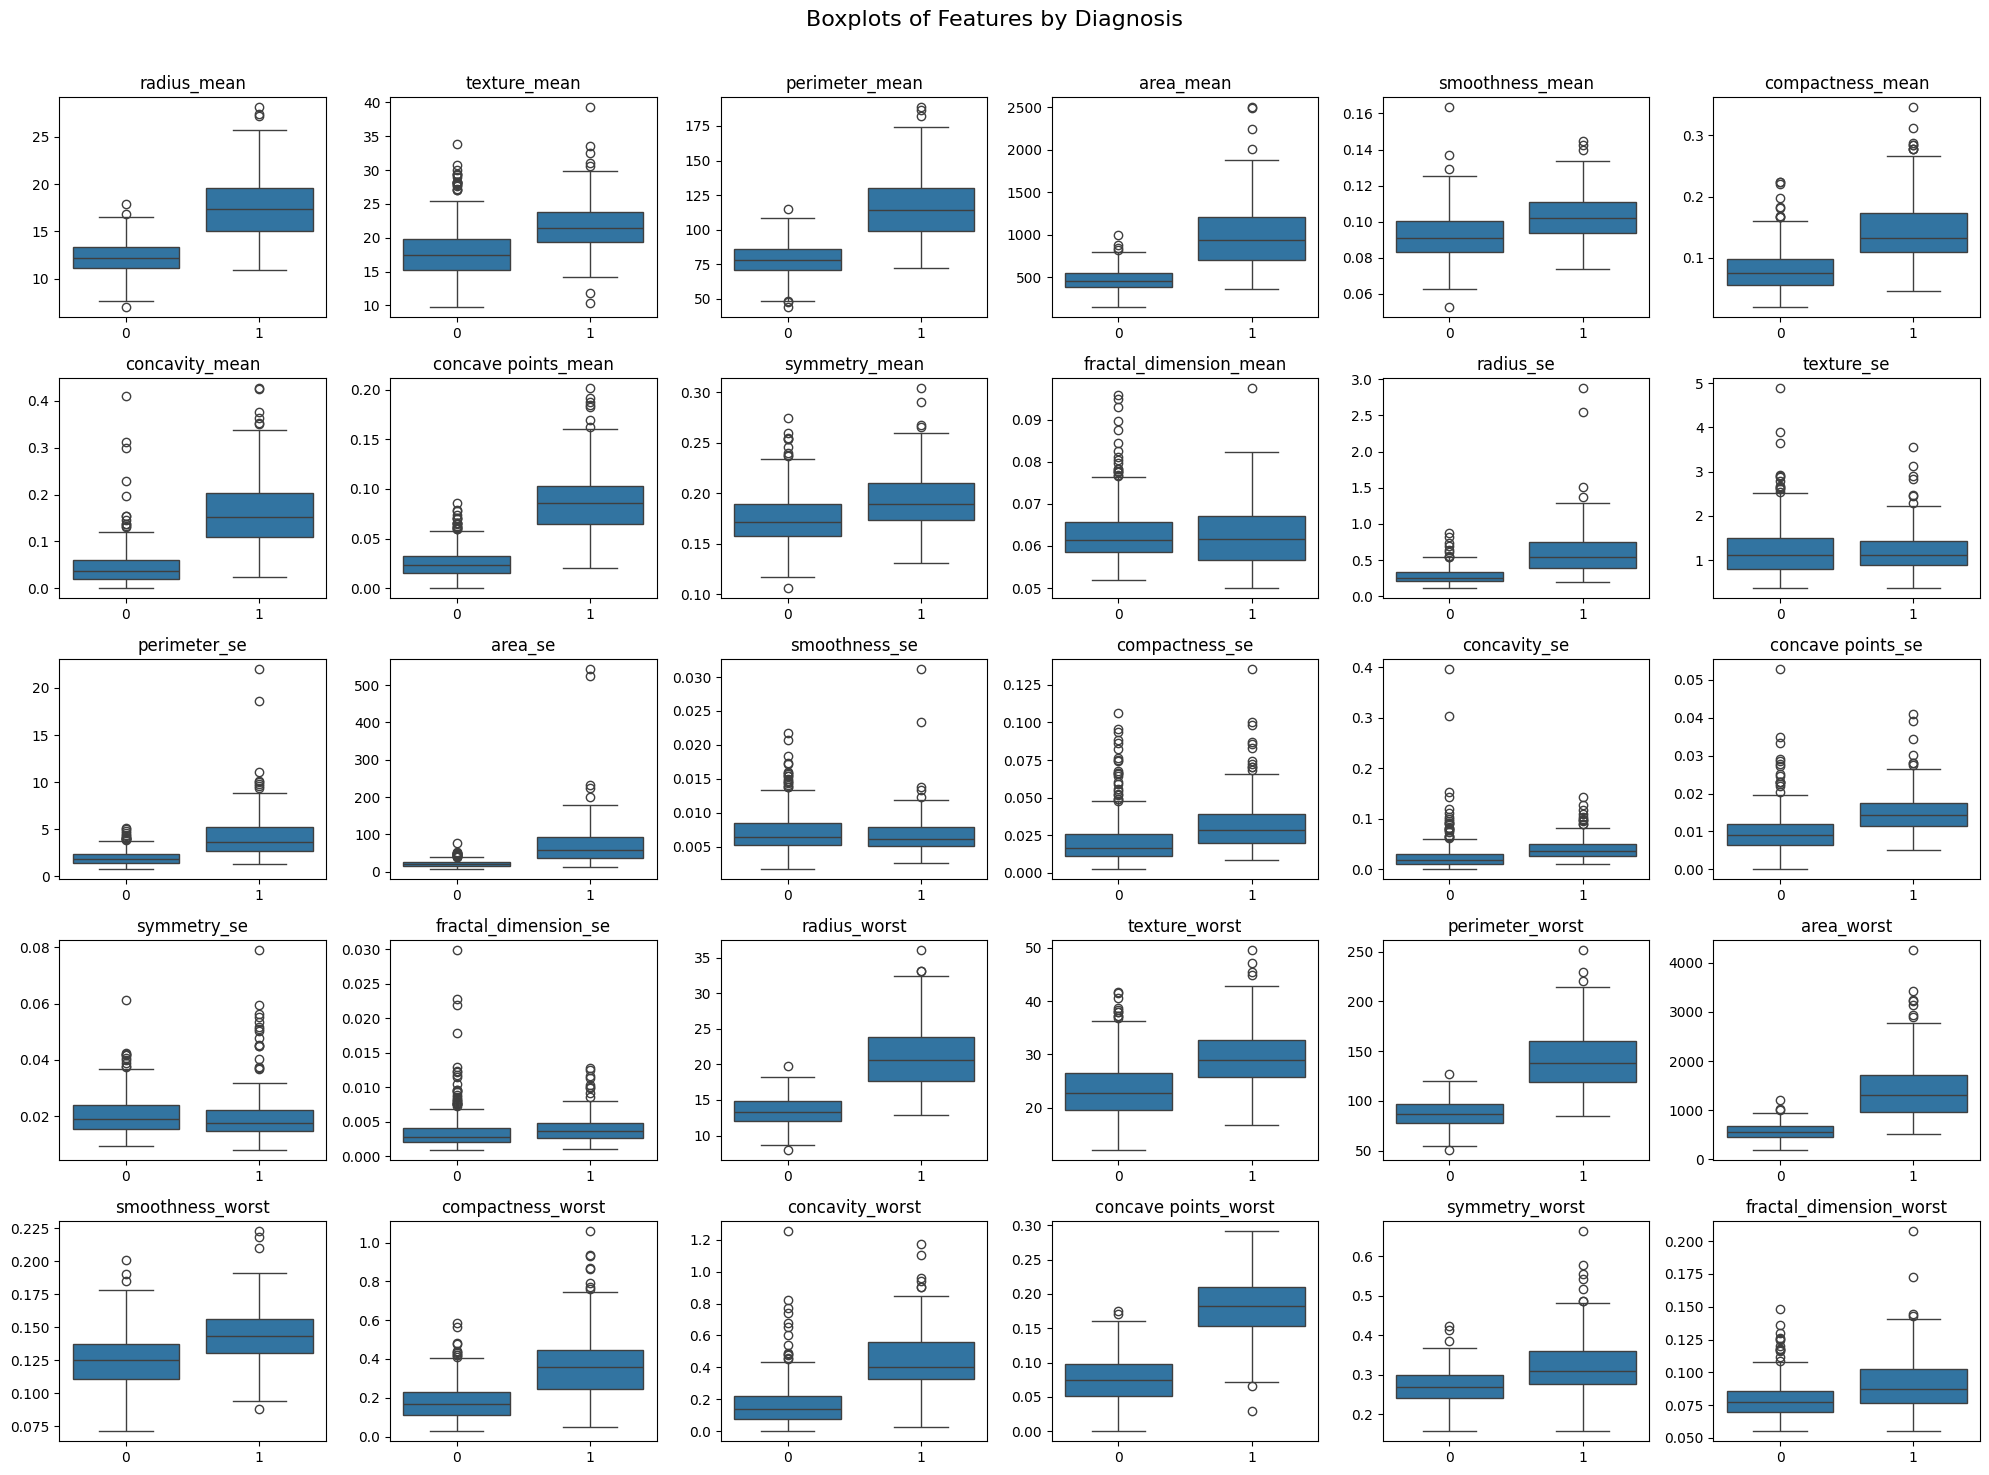

In [ ]:
#boxplots

import matplotlib.pyplot as plt
import seaborn as sns
cols = df.drop(["id", "diagnosis"], axis=1, errors='ignore').columns.tolist()
num_cols = len(cols)

# Set up grid size (e.g., 5 rows x 6 columns for 30 features)
rows = 5
cols_per_row = 6

# Create subplots
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, 15))
fig.suptitle('Boxplots of Features by Diagnosis', fontsize=16)

# Flatten axes for easy iteration
axes = axes.flatten()

# Plot each feature
for i, col in enumerate(df.drop(["id", "diagnosis"], axis=1, errors='ignore').columns):
    sns.boxplot(x='diagnosis', y=col, data=df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.97])  # Leave space for suptitle
plt.show()

c. Pen down your intuitions and provide a brief analytical summary of data.

In [ ]:
df=df.drop("id",axis=1)
feature = df.columns.tolist()
outlier_dict = {}
for col in feature:
    if df[col].dtype not in ['float64', 'int64']:
        continue
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_rows = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
    #print(f"Number of outliers in '{col}': {outlier_rows.shape[0]}")
    outlier_dict[col] = outlier_rows.shape[0]
outlier_dict

{'diagnosis': 0,
 'radius_mean': 14,
 'texture_mean': 7,
 'perimeter_mean': 13,
 'area_mean': 25,
 'smoothness_mean': 6,
 'compactness_mean': 16,
 'concavity_mean': 18,
 'concave points_mean': 10,
 'symmetry_mean': 15,
 'fractal_dimension_mean': 15,
 'radius_se': 38,
 'texture_se': 20,
 'perimeter_se': 38,
 'area_se': 65,
 'smoothness_se': 30,
 'compactness_se': 28,
 'concavity_se': 22,
 'concave points_se': 19,
 'symmetry_se': 27,
 'fractal_dimension_se': 28,
 'radius_worst': 17,
 'texture_worst': 5,
 'perimeter_worst': 15,
 'area_worst': 35,
 'smoothness_worst': 7,
 'compactness_worst': 16,
 'concavity_worst': 12,
 'concave points_worst': 0,
 'symmetry_worst': 23,
 'fractal_dimension_worst': 24}

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [ ]:
df.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


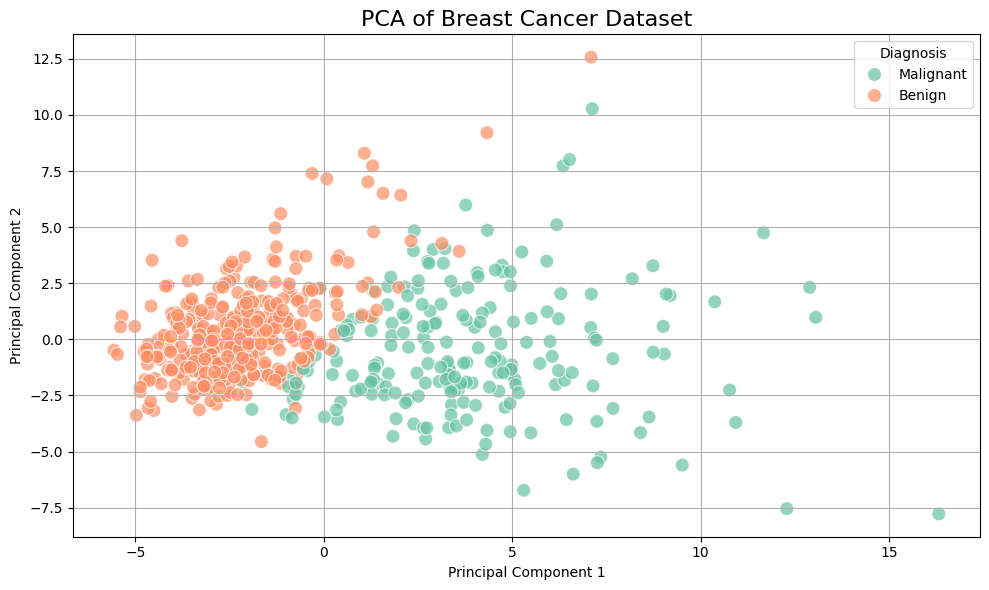

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer


df = pd.read_csv("/content/data - data (1).csv")

# Step 3: Clean Data
df.columns = df.columns.str.strip()
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')  # Drop irrelevant columns
df['diagnosis'] = df['diagnosis'].astype(str).str.strip().str.upper()
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})  # Encode target

# Step 4: Prepare X and y
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']
y_labels = y.map({1: 'Malignant', 0: 'Benign'})

# Step 5: Handle Missing Values
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Step 6: Standardize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Step 7: Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 8: Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_labels, palette='Set2', s=100, alpha=0.7)
plt.title("PCA of Breast Cancer Dataset", fontsize=16)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Diagnosis")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(['diagnosis'], axis=1)
y = df['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (455, 30)
Testing set shape: (114, 30)


##d. Train the following classification models:

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

target_col = 'diagnosis'
X = df.drop(columns=[target_col])
y = df[target_col]

# First split into train + temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# Split temp into val and test (each 15% of original data)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Scale features for train, val, and test sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [ ]:
import time
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(max_iter=5000, random_state=42)
start = time.time()
model.fit(X_train_scaled, y_train)
train_time = time.time() - start

y_pred = model.predict(X_val_scaled)
acc = accuracy_score(y_val, y_pred)

print(f"Logistic Regression Accuracy: {acc:.4f}")
print(f"Training Time: {train_time:.4f} seconds")



Logistic Regression Accuracy: 0.9647
Training Time: 0.0070 seconds


In [ ]:
from sklearn.tree import DecisionTreeClassifier


model = DecisionTreeClassifier(random_state=42)
start = time.time()
model.fit(X_train, y_train)  # Decision tree can work without scaling
train_time = time.time() - start

y_pred = model.predict(X_val)
acc = accuracy_score(y_val, y_pred)

print(f"Decision Tree Accuracy: {acc:.4f}")
print(f"Training Time: {train_time:.4f} seconds")



Decision Tree Accuracy: 0.8941
Training Time: 0.0148 seconds


In [ ]:
from sklearn.neighbors import KNeighborsClassifier


model = KNeighborsClassifier()
start = time.time()
model.fit(X_train_scaled, y_train)
train_time = time.time() - start

y_pred = model.predict(X_val_scaled)
acc = accuracy_score(y_val, y_pred)

print(f"k-NN Accuracy: {acc:.4f}")
print(f"Training Time: {train_time:.4f} seconds")


k-NN Accuracy: 0.9647
Training Time: 0.0031 seconds


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model = SVC(random_state=42)
start = time.time()
model.fit(X_train_scaled, y_train)
train_time = time.time() - start

y_pred = model.predict(X_val_scaled)
acc = accuracy_score(y_val, y_pred)

print(f"SVM Accuracy: {acc:.4f}")
print(f"Training Time: {train_time:.4f} seconds")



SVM Accuracy: 0.9529
Training Time: 0.0204 seconds


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

model = GaussianNB()
start = time.time()
model.fit(X_train_scaled, y_train)
train_time = time.time() - start

y_pred = model.predict(X_val_scaled)
acc = accuracy_score(y_val, y_pred)

print(f"Naive Bayes Accuracy: {acc:.4f}")
print(f"Training Time: {train_time:.4f} seconds")


Naive Bayes Accuracy: 0.9294
Training Time: 0.0023 seconds


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(random_state=42)
start = time.time()
model.fit(X_train, y_train)  # Random Forest works fine without scaling
train_time = time.time() - start

y_pred = model.predict(X_val)
acc = accuracy_score(y_val, y_pred)

print(f"Random Forest Accuracy: {acc:.4f}")
print(f"Training Time: {train_time:.4f} seconds")


Random Forest Accuracy: 0.9647
Training Time: 0.2461 seconds


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score

model = ExtraTreesClassifier(random_state=42)
start = time.time()
model.fit(X_train, y_train)  # No scaling needed
train_time = time.time() - start

y_pred = model.predict(X_val)
acc = accuracy_score(y_val, y_pred)

print(f"Extra Trees Accuracy: {acc:.4f}")
print(f"Training Time: {train_time:.4f} seconds")


Extra Trees Accuracy: 0.9529
Training Time: 0.2299 seconds


##e. Compare these algorithms on the basis of the following:

 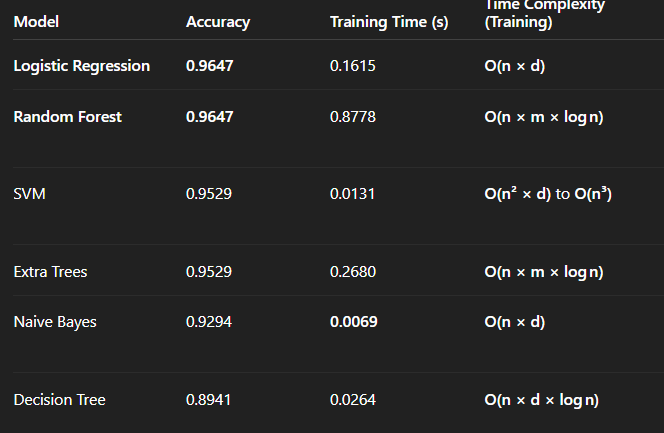

###obtained from models above

##g. Deploy the trained model (best one).


In [ ]:
best_model = LogisticRegression()
best_model.fit(X_train, y_train)

# Manually entered input from the table
input_data = [[14.6, 22.7, 96.4, 657, 0.085, 0.133, 0.103, 0.04, 0.1654, 0.05147,
               0.3354, 1.108, 2.244, 19.74, 0.004342, 0.04649, 0.06578, 0.01506,
               0.01738, 0.0045406, 13.48, 37.27, 105.9, 734.5, 0.1206, 0.317,
               0.3682, 0.1305, 0.2348, 0.08004]]

input_scaled = scaler.transform(input_data)
prediction = best_model.predict(input_scaled)

print("Prediction:", "Malignant (M)" if prediction[0]==1 else "Benign (B)")

Prediction: Malignant (M)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
